In [8]:
# ============================================
# ЯЧЕЙКА 1: Импорт библиотек и настройка GPU
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import warnings
warnings.filterwarnings('ignore')

# Настройка устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Используется устройство: {device}")
if torch.cuda.is_available():
    print(f" GPU: {torch.cuda.get_device_name(0)}")

 Используется устройство: cuda
 GPU: NVIDIA GeForce RTX 3060


In [9]:
# ============================================
# ЯЧЕЙКА 2: Загрузка Japanese Vowels
# ============================================

print("=== ЗАГРУЗКА JAPANESE VOWELS ===\n")

def download_vowels():
    """Скачивает данные Japanese Vowels напрямую с UCI"""
    train_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/JapaneseVowels-mld/ae.train"
    test_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/JapaneseVowels-mld/ae.test"
    
    def parse_file(url, speaker_counts):
        response = urllib.request.urlopen(url)
        content = response.read().decode('utf-8')
        
        sequences = []
        labels = []
        current_seq = []
        speaker_id = 0
        block_idx = 0
        
        for line in content.split('\n'):
            line = line.strip()
            if not line:  # Пустая строка — разделитель
                if current_seq:
                    sequences.append(np.array(current_seq))
                    labels.append(speaker_id)
                    current_seq = []
                    block_idx += 1
                    
                    if block_idx >= speaker_counts[speaker_id]:
                        speaker_id += 1
                        block_idx = 0
                        if speaker_id >= len(speaker_counts):
                            break
            else:
                values = [float(x) for x in line.split()]
                if len(values) == 12:
                    current_seq.append(values)
        
        return sequences, np.array(labels)
    
    train_counts = [30] * 9  # 9 спикеров, по 30 записей
    test_counts = [31, 35, 88, 44, 29, 24, 40, 50, 29]
    
    X_train, y_train = parse_file(train_url, train_counts)
    X_test, y_test = parse_file(test_url, test_counts)
    
    # Объединяем train и test
    X_all = X_train + X_test
    y_all = np.concatenate([y_train, y_test])
    
    return X_all, y_all

# Загрузка данных
X_list, y_array = download_vowels()

# Преобразование в тензоры
sequences = [torch.FloatTensor(seq) for seq in X_list]
labels = torch.LongTensor(y_array)

print(f" Загружено {len(sequences)} последовательностей")
print(f" Количество классов: {len(torch.unique(labels))}")
print(f" Размерность признаков: {sequences[0].shape[1]}")
print(f" Диапазон длин: {min(len(s) for s in sequences)} - {max(len(s) for s in sequences)}")
print(f" Распределение классов:")
unique, counts = torch.unique(labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"   Класс {u}: {c} образцов")

=== ЗАГРУЗКА JAPANESE VOWELS ===

 Загружено 640 последовательностей
 Количество классов: 9
 Размерность признаков: 12
 Диапазон длин: 7 - 29
 Распределение классов:
   Класс 0: 61 образцов
   Класс 1: 65 образцов
   Класс 2: 118 образцов
   Класс 3: 74 образцов
   Класс 4: 59 образцов
   Класс 5: 54 образцов
   Класс 6: 70 образцов
   Класс 7: 80 образцов
   Класс 8: 59 образцов


In [10]:
# ============================================
# ЯЧЕЙКА 3: Создание DataLoader
# ============================================

print("\n=== СОЗДАНИЕ DATALOADER ===\n")

def collate_fn(batch):
    """Объединяет последовательности разной длины с padding"""
    sequences, labels = zip(*batch)
    max_len = max(seq.shape[0] for seq in sequences)
    n_features = sequences[0].shape[1]
    
    padded_seqs = torch.zeros(len(sequences), max_len, n_features)
    lengths = []
    
    for i, seq in enumerate(sequences):
        lengths.append(seq.shape[0])
        padded_seqs[i, :seq.shape[0], :] = seq
    
    return padded_seqs, torch.stack(labels), torch.tensor(lengths)

# Разделение на train/val/test
indices = np.random.permutation(len(sequences))
train_idx = indices[:int(0.7 * len(indices))]
val_idx = indices[int(0.7 * len(indices)):int(0.85 * len(indices))]
test_idx = indices[int(0.85 * len(indices)):]

train_data = [(sequences[i], labels[i]) for i in train_idx]
val_data = [(sequences[i], labels[i]) for i in val_idx]
test_data = [(sequences[i], labels[i]) for i in test_idx]

batch_size = 32
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

print(f"Train: {len(train_data)} последовательностей")
print(f"Val: {len(val_data)} последовательностей")
print(f"Test: {len(test_data)} последовательностей")
print(f"Batch size: {batch_size}")


=== СОЗДАНИЕ DATALOADER ===

Train: 448 последовательностей
Val: 96 последовательностей
Test: 96 последовательностей
Batch size: 32


In [13]:
# ============================================
# ЯЧЕЙКА 4: Проверка загрузки
# ============================================

print("=== ПРОВЕРКА ===\n")

for data, targets, lengths in train_loader:
    print(f"Batch data shape: {data.shape}")
    print(f"Batch targets shape: {targets.shape}")
    print(f"Lengths: {lengths[:5]}")
    print(f"Уникальные классы в батче: {torch.unique(targets)}")
    break

print("\nВсё работает!")

=== ПРОВЕРКА ===

Batch data shape: torch.Size([32, 25, 12])
Batch targets shape: torch.Size([32])
Lengths: tensor([13, 16, 15, 15, 12])
Уникальные классы в батче: tensor([0, 1, 2, 3, 5, 6, 7, 8])

Всё работает!


In [14]:
# ============================================
# ЯЧЕЙКА 5: Архитектуры моделей
# ============================================

class RNNModel(nn.Module):
    """Простая RNN"""
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.3):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, hidden = self.rnn(packed)
        return self.fc(self.dropout(hidden[-1]))

class LSTMModel(nn.Module):
    """LSTM"""
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed)
        return self.fc(self.dropout(hidden[-1]))

class GRUModel(nn.Module):
    """Bidirectional GRU"""
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.3):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, num_classes)
    
    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, hidden = self.gru(packed)
        last_forward = hidden[-2]
        last_backward = hidden[-1]
        last_hidden = torch.cat((last_forward, last_backward), dim=1)
        return self.fc(self.dropout(last_hidden))

print("Архитектуры моделей определены")

Архитектуры моделей определены


In [15]:
# ============================================
# ЯЧЕЙКА 6: Функция обучения
# ============================================

def train_model(model, train_loader, val_loader, epochs=30, lr=0.001):
    """Обучение модели"""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    best_val_acc = 0
    train_accs = []
    val_accs = []
    
    for epoch in range(epochs):
        # Train
        model.train()
        train_correct, train_total = 0, 0
        
        for data, targets, lengths in train_loader:
            data, targets = data.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(data, lengths)
            loss = criterion(outputs, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            train_correct += (outputs.argmax(1) == targets).sum().item()
            train_total += targets.size(0)
        
        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        
        with torch.no_grad():
            for data, targets, lengths in val_loader:
                data, targets = data.to(device), targets.to(device)
                outputs = model(data, lengths)
                val_correct += (outputs.argmax(1) == targets).sum().item()
                val_total += targets.size(0)
        
        train_acc = 100. * train_correct / train_total
        val_acc = 100. * val_correct / val_total
        
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
        scheduler.step(100 - val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
        
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}/{epochs} - Train Acc: {train_acc:.1f}%, Val Acc: {val_acc:.1f}%")
    
    return best_val_acc, val_accs, train_accs

print("Функция обучения определена")

Функция обучения определена


In [17]:
# ============================================
# ЯЧЕЙКА 7: Запуск экспериментов
# ============================================

print("=== ЭКСПЕРИМЕНТЫ НА JAPANESE VOWELS ===\n")

input_size = sequences[0].shape[1]  # 12
num_classes = len(torch.unique(labels))  # 9
num_layers = 2
hidden_sizes = [64, 128]
epochs = 25

results = {}

for hidden_size in hidden_sizes:
    for model_class, model_name in [(RNNModel, "RNN"), (LSTMModel, "LSTM"), (GRUModel, "GRU")]:
        print(f"\n {model_name} (hidden={hidden_size})")
        model = model_class(input_size, hidden_size, num_layers, num_classes)
        best_acc, val_accs, train_accs = train_model(model, train_loader, val_loader, epochs=epochs)
        results[f"{model_name}_h{hidden_size}"] = {
            'best_val_acc': best_acc,
            'val_accs': val_accs,
            'train_accs': train_accs
        }
        print(f"  Лучшая Val Acc: {best_acc:.1f}%")

=== ЭКСПЕРИМЕНТЫ НА JAPANESE VOWELS ===


 RNN (hidden=64)
  Epoch 10/25 - Train Acc: 65.6%, Val Acc: 63.5%
  Epoch 20/25 - Train Acc: 85.7%, Val Acc: 82.3%
  Лучшая Val Acc: 88.5%

 LSTM (hidden=64)
  Epoch 10/25 - Train Acc: 74.8%, Val Acc: 80.2%
  Epoch 20/25 - Train Acc: 93.1%, Val Acc: 87.5%
  Лучшая Val Acc: 93.8%

 GRU (hidden=64)
  Epoch 10/25 - Train Acc: 91.1%, Val Acc: 90.6%
  Epoch 20/25 - Train Acc: 98.9%, Val Acc: 91.7%
  Лучшая Val Acc: 95.8%

 RNN (hidden=128)
  Epoch 10/25 - Train Acc: 77.5%, Val Acc: 75.0%
  Epoch 20/25 - Train Acc: 93.8%, Val Acc: 91.7%
  Лучшая Val Acc: 92.7%

 LSTM (hidden=128)
  Epoch 10/25 - Train Acc: 85.9%, Val Acc: 82.3%
  Epoch 20/25 - Train Acc: 96.9%, Val Acc: 93.8%
  Лучшая Val Acc: 94.8%

 GRU (hidden=128)
  Epoch 10/25 - Train Acc: 96.7%, Val Acc: 92.7%
  Epoch 20/25 - Train Acc: 99.3%, Val Acc: 94.8%
  Лучшая Val Acc: 95.8%



=== РЕЗУЛЬТАТЫ ===

Модель  Hidden Size  Val Acc (%)
   GRU          128        95.83
   GRU           64        95.83
  LSTM          128        94.79
  LSTM           64        93.75
   RNN          128        92.71
   RNN           64        88.54


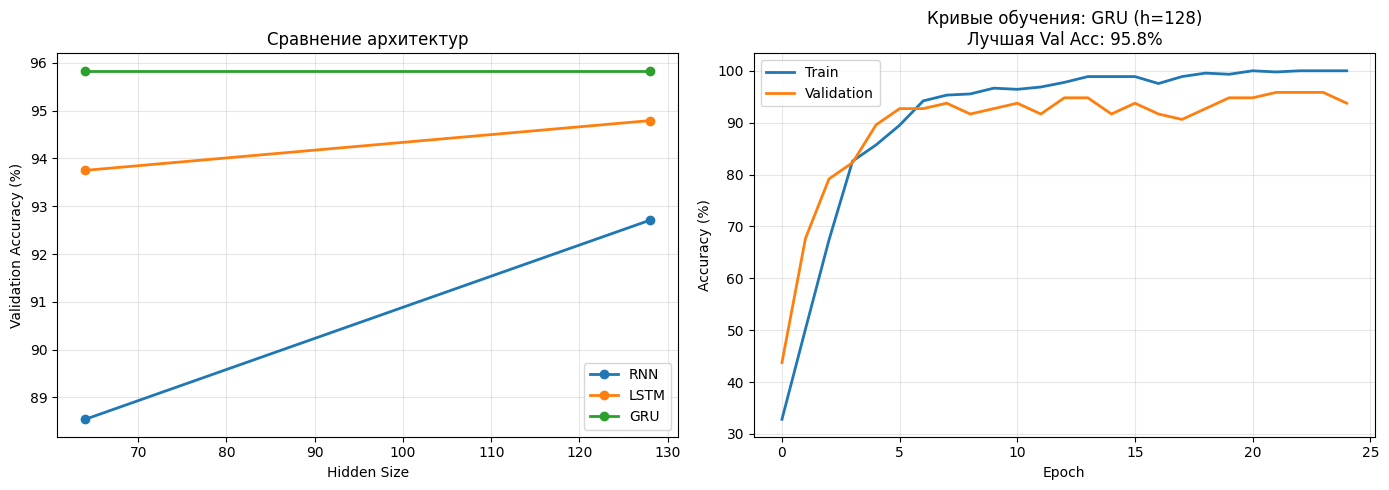


Лучшая модель: GRU с hidden_size=128
   Val Accuracy: 95.8%


In [18]:
# ============================================
# ЯЧЕЙКА 8: Результаты и визуализация
# ============================================

print("\n=== РЕЗУЛЬТАТЫ ===\n")

results_df = pd.DataFrame([{
    'Модель': name.split('_')[0],
    'Hidden Size': int(name.split('_h')[1]),
    'Val Acc (%)': round(data['best_val_acc'], 2)
} for name, data in results.items()]).sort_values('Val Acc (%)', ascending=False)

print(results_df.to_string(index=False))

# График
plt.figure(figsize=(14, 5))

# Сравнение архитектур
plt.subplot(1, 2, 1)
for model_type in ['RNN', 'LSTM', 'GRU']:
    accs = []
    for hs in hidden_sizes:
        key = f"{model_type}_h{hs}"
        if key in results:
            accs.append(results[key]['best_val_acc'])
    plt.plot(hidden_sizes, accs, marker='o', linewidth=2, label=model_type)

plt.xlabel('Hidden Size')
plt.ylabel('Validation Accuracy (%)')
plt.title('Сравнение архитектур')
plt.legend()
plt.grid(True, alpha=0.3)

# Кривые обучения лучшей модели
plt.subplot(1, 2, 2)
best_model = results_df.iloc[0]['Модель']
best_hs = results_df.iloc[0]['Hidden Size']
best_key = f"{best_model}_h{best_hs}"

plt.plot(results[best_key]['train_accs'], label='Train', linewidth=2)
plt.plot(results[best_key]['val_accs'], label='Validation', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title(f'Кривые обучения: {best_model} (h={best_hs})\nЛучшая Val Acc: {results_df.iloc[0]["Val Acc (%)"]:.1f}%')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nЛучшая модель: {best_model} с hidden_size={best_hs}")
print(f"   Val Accuracy: {results_df.iloc[0]['Val Acc (%)']:.1f}%")

In [19]:
# ============================================
# ЯЧЕЙКА 9: Определение и обучение лучшей модели
# ============================================

print("=== ОПРЕДЕЛЕНИЕ ЛУЧШЕЙ МОДЕЛИ ===\n")

# Находим лучшую модель из результатов
best_model_name = results_df.iloc[0]['Модель']
best_hidden = int(results_df.iloc[0]['Hidden Size'])
best_val_acc = results_df.iloc[0]['Val Acc (%)']

print(f"Лучшая модель по валидации:")
print(f"  Архитектура: {best_model_name}")
print(f"  Hidden size: {best_hidden}")
print(f"  Val Accuracy: {best_val_acc:.2f}%")

# Выбираем класс модели
if best_model_name == 'RNN':
    BestModelClass = RNNModel
elif best_model_name == 'LSTM':
    BestModelClass = LSTMModel
else:
    BestModelClass = GRUModel

print(f"\nБудет использована: {BestModelClass.__name__}")

=== ОПРЕДЕЛЕНИЕ ЛУЧШЕЙ МОДЕЛИ ===

Лучшая модель по валидации:
  Архитектура: GRU
  Hidden size: 128
  Val Accuracy: 95.83%

Будет использована: GRUModel


In [21]:
# ============================================
# ЯЧЕЙКА 10: Обучение лучшей модели на всех данных
# ============================================

print("=== ОБУЧЕНИЕ ЛУЧШЕЙ МОДЕЛИ ===\n")

# Объединяем train и val для финального обучения
full_train_data = train_data + val_data
full_train_loader = DataLoader(full_train_data, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)

input_size = sequences[0].shape[1]
num_classes = len(torch.unique(labels))
num_layers = 2

# Создаём модель
best_model = BestModelClass(input_size, best_hidden, num_layers, num_classes)
best_model = best_model.to(device)

# Параметры обучения
epochs_final = 30
learning_rate = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(best_model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

print(f"Параметры финального обучения:")
print(f"  Эпох: {epochs_final}")
print(f"  Learning rate: {learning_rate}")
print(f"  Размер батча: {batch_size}")
print(f"  Обучающих: {len(full_train_data)}")

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(epochs_final):
    # Обучение
    best_model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for data, targets, lengths in full_train_loader:
        data, targets = data.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = best_model(data, lengths)
        loss = criterion(outputs, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(best_model.parameters(), 1.0)
        optimizer.step()
        
        train_loss += loss.item()
        train_correct += (outputs.argmax(1) == targets).sum().item()
        train_total += targets.size(0)
    
    # Валидация на тестовой выборке
    best_model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for data, targets, lengths in test_loader:
            data, targets = data.to(device), targets.to(device)
            outputs = best_model(data, lengths)
            loss = criterion(outputs, targets)
            
            val_loss += loss.item()
            val_correct += (outputs.argmax(1) == targets).sum().item()
            val_total += targets.size(0)
    
    train_acc = 100. * train_correct / train_total
    val_acc = 100. * val_correct / val_total
    
    train_losses.append(train_loss / len(full_train_loader))
    val_losses.append(val_loss / len(test_loader))
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    scheduler.step(val_losses[-1])
    
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1}/{epochs_final} - Train Acc: {train_acc:.2f}%, Test Acc: {val_acc:.2f}%")

print(f"\nОбучение завершено!")
print(f"  Финальная Test Accuracy: {val_acc:.2f}%")
print(f"  Лучшая Test Accuracy: {max(val_accs):.2f}%")

=== ОБУЧЕНИЕ ЛУЧШЕЙ МОДЕЛИ ===

Параметры финального обучения:
  Эпох: 30
  Learning rate: 0.001
  Размер батча: 32
  Обучающих: 544
  Epoch 5/30 - Train Acc: 93.01%, Test Acc: 90.62%
  Epoch 10/30 - Train Acc: 96.32%, Test Acc: 94.79%
  Epoch 15/30 - Train Acc: 97.24%, Test Acc: 95.83%
  Epoch 20/30 - Train Acc: 99.63%, Test Acc: 98.96%
  Epoch 25/30 - Train Acc: 100.00%, Test Acc: 95.83%
  Epoch 30/30 - Train Acc: 100.00%, Test Acc: 95.83%

Обучение завершено!
  Финальная Test Accuracy: 95.83%
  Лучшая Test Accuracy: 98.96%


In [22]:
# ============================================
# ЯЧЕЙКА 11: Детальный анализ на тестовой выборке
# ============================================

print("=== ДЕТАЛЬНЫЙ АНАЛИЗ НА ТЕСТОВОЙ ВЫБОРКЕ ===\n")

best_model.eval()
all_preds = []
all_targets = []
all_probs = []

with torch.no_grad():
    for data, targets, lengths in test_loader:
        data, targets = data.to(device), targets.to(device)
        outputs = best_model(data, lengths)
        probabilities = torch.softmax(outputs, dim=1)
        predictions = outputs.argmax(1)
        
        all_preds.extend(predictions.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())
        all_probs.extend(probabilities.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
all_probs = np.array(all_probs)

# Основные метрики
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

test_accuracy = accuracy_score(all_targets, all_preds) * 100
precision = precision_score(all_targets, all_preds, average='weighted') * 100
recall = recall_score(all_targets, all_preds, average='weighted') * 100
f1 = f1_score(all_targets, all_preds, average='weighted') * 100

print(f"МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ:")
print(f"  {'='*40}")
print(f"  Accuracy:  {test_accuracy:.2f}%")
print(f"  Precision: {precision:.2f}%")
print(f"  Recall:    {recall:.2f}%")
print(f"  F1-Score:  {f1:.2f}%")
print(f"  {'='*40}")

# По классам
from sklearn.metrics import classification_report
print(f"\nДЕТАЛЬНЫЙ ОТЧЁТ ПО КЛАССАМ:")
print(classification_report(all_targets, all_preds))

=== ДЕТАЛЬНЫЙ АНАЛИЗ НА ТЕСТОВОЙ ВЫБОРКЕ ===

МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ:
  Accuracy:  95.83%
  Precision: 96.05%
  Recall:    95.83%
  F1-Score:  95.80%

ДЕТАЛЬНЫЙ ОТЧЁТ ПО КЛАССАМ:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        16
           2       0.89      1.00      0.94        17
           3       1.00      1.00      1.00        16
           4       1.00      1.00      1.00         9
           5       1.00      1.00      1.00         3
           6       1.00      0.83      0.91        12
           7       0.89      0.89      0.89         9
           8       0.86      0.86      0.86         7

    accuracy                           0.96        96
   macro avg       0.96      0.95      0.96        96
weighted avg       0.96      0.96      0.96        96



=== МАТРИЦА ОШИБОК ===



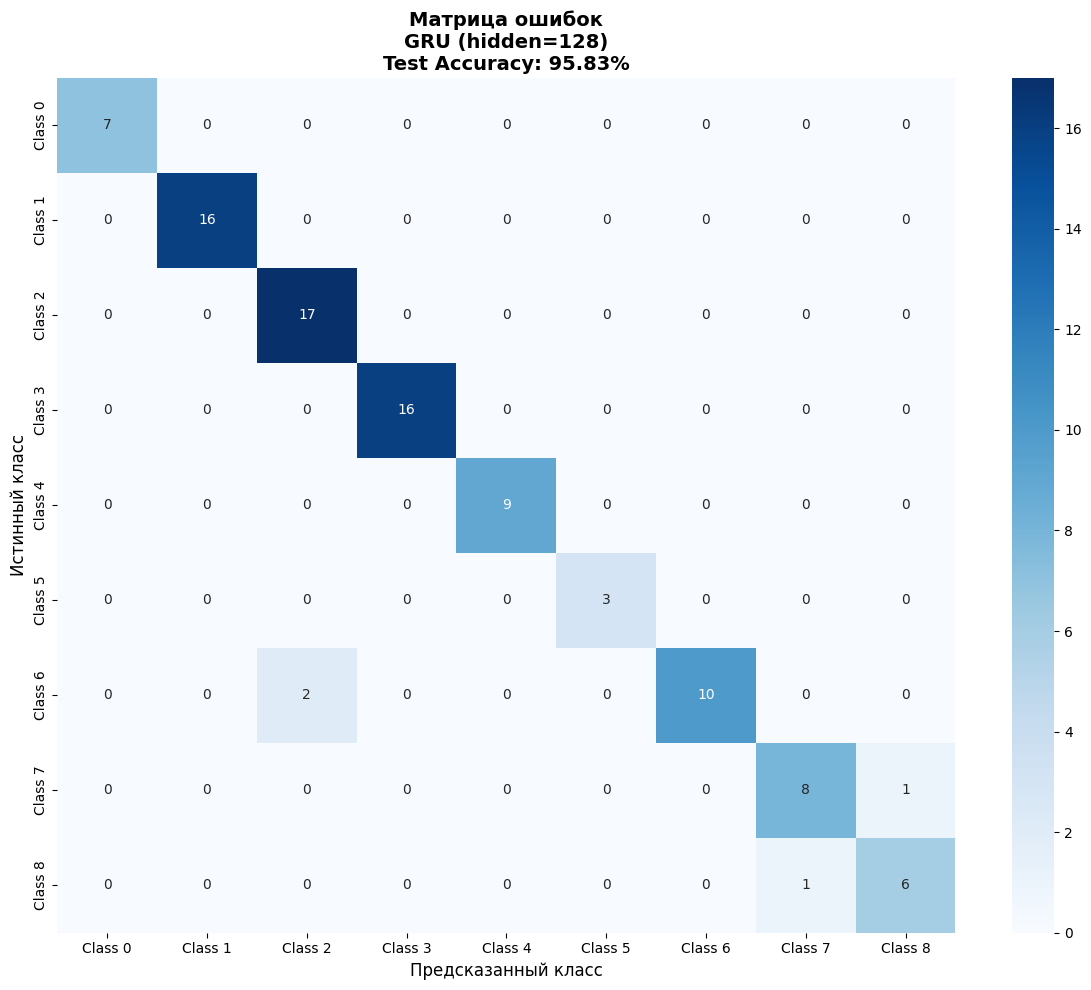


Анализ ошибок:
  Всего тестовых примеров: 96
  Ошибочно классифицировано: 4 / 96 (4.2%)

  Самые частые ошибки:
    Класс 6 -> 2: 2 раз(а)
    Класс 7 -> 8: 1 раз(а)
    Класс 8 -> 7: 1 раз(а)


In [23]:
# ============================================
# ЯЧЕЙКА 12: Матрица ошибок
# ============================================

print("=== МАТРИЦА ОШИБОК ===\n")

cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Class {i}' for i in range(num_classes)],
            yticklabels=[f'Class {i}' for i in range(num_classes)])

plt.title(f'Матрица ошибок\n{best_model_name} (hidden={best_hidden})\nTest Accuracy: {test_accuracy:.2f}%', 
          fontsize=14, fontweight='bold')
plt.xlabel('Предсказанный класс', fontsize=12)
plt.ylabel('Истинный класс', fontsize=12)
plt.tight_layout()
plt.show()

# Анализ ошибок
misclassified = (all_preds != all_targets)
misclassified_mask = all_targets != all_preds

print(f"\nАнализ ошибок:")
print(f"  Всего тестовых примеров: {len(all_targets)}")
print(f"  Ошибочно классифицировано: {misclassified.sum()} / {len(all_targets)} ({100*misclassified.sum()/len(all_targets):.1f}%)")

# Какие классы чаще всего путаются
if misclassified.sum() > 0:
    error_pairs = []
    for i in range(len(all_targets)):
        if misclassified[i]:
            error_pairs.append((all_targets[i], all_preds[i]))
    
    error_df = pd.DataFrame(error_pairs, columns=['True', 'Pred'])
    print(f"\n  Самые частые ошибки:")
    for (true_class, pred_class), count in error_df.value_counts().head(5).items():
        print(f"    Класс {true_class} -> {pred_class}: {count} раз(а)")

=== ВИЗУАЛИЗАЦИЯ ПРЕДСКАЗАНИЙ ===



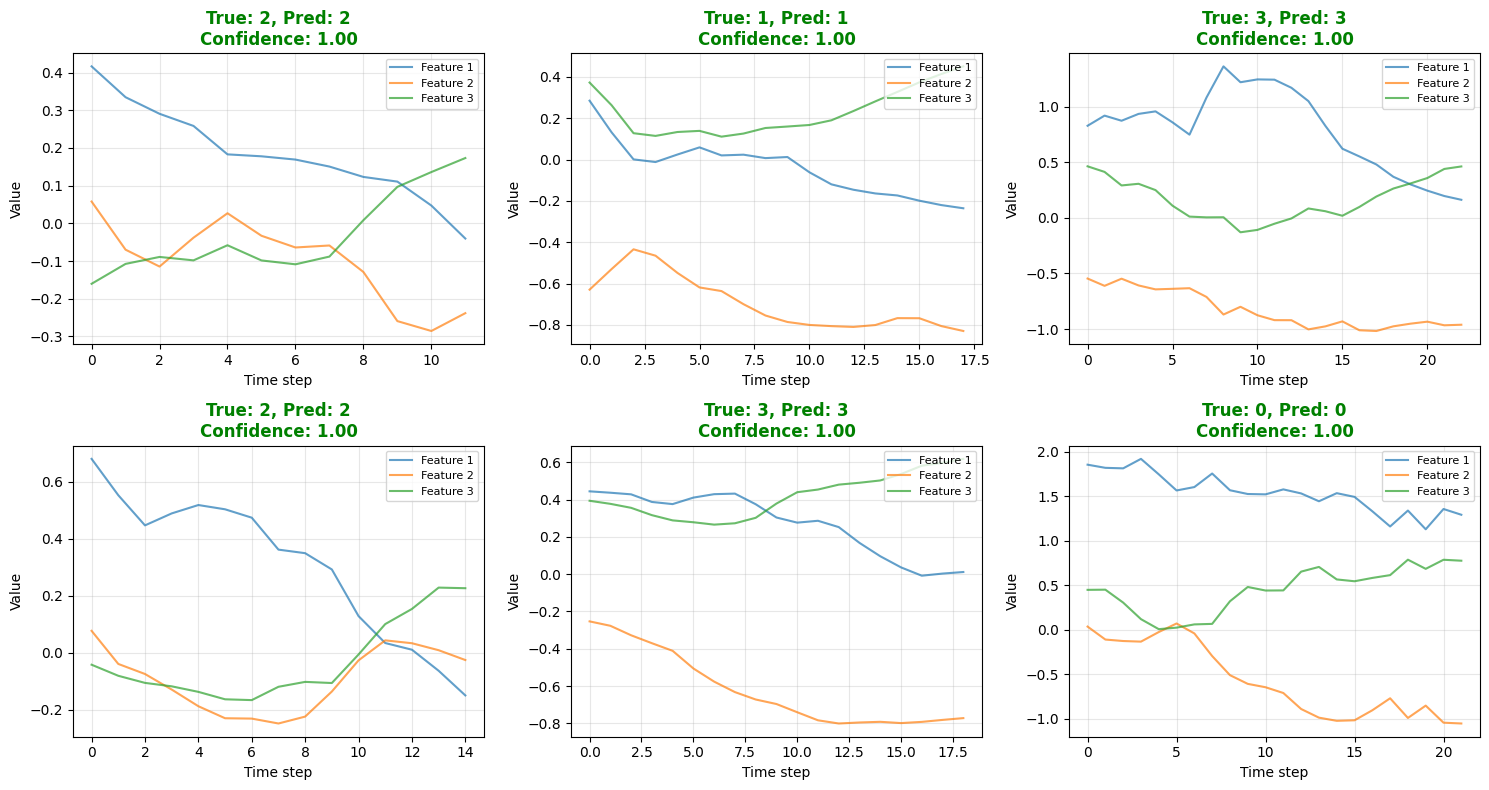

In [24]:
# ============================================
# ЯЧЕЙКА 13: Визуализация предсказаний модели
# ============================================

print("=== ВИЗУАЛИЗАЦИЯ ПРЕДСКАЗАНИЙ ===\n")

# Выбираем несколько случайных примеров из тестовой выборки
n_examples = 6
sample_indices = np.random.choice(len(test_data), n_examples, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, sample_idx in enumerate(sample_indices):
    # Получаем данные
    seq, true_label = test_data[sample_idx]
    seq = seq.unsqueeze(0).to(device)  # добавляем batch dimension
    length = torch.tensor([seq.shape[1]]).to(device)
    
    # Предсказание
    with torch.no_grad():
        output = best_model(seq, length)
        prob = torch.softmax(output, dim=1)
        pred_label = output.argmax(1).item()
    
    # Визуализация (первые 3 признака для наглядности)
    seq_np = seq.cpu().squeeze().numpy()
    for f in range(min(3, seq_np.shape[1])):
        axes[idx].plot(seq_np[:, f], alpha=0.7, label=f'Feature {f+1}')
    
    # Оформление
    color = 'green' if pred_label == true_label else 'red'
    axes[idx].set_title(f'True: {true_label}, Pred: {pred_label}\nConfidence: {prob[0][pred_label].item():.2f}',
                        color=color, fontweight='bold')
    axes[idx].set_xlabel('Time step')
    axes[idx].set_ylabel('Value')
    axes[idx].legend(loc='upper right', fontsize=8)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
# ============================================
# ЯЧЕЙКА 14: Сохранение модели и результатов
# ============================================

print("=== СОХРАНЕНИЕ РЕЗУЛЬТАТОВ ===\n")

# Сохраняем модель
model_path = f'best_model_{best_model_name}_h{best_hidden}.pth'
torch.save(best_model.state_dict(), model_path)
print(f"Модель сохранена: {model_path}")

# Сохраняем результаты в CSV
results_summary = {
    'Модель': best_model_name,
    'Hidden Size': best_hidden,
    'Val Accuracy': best_val_acc,
    'Test Accuracy': test_accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1,
    'Epochs': epochs_final,
    'Learning Rate': learning_rate,
    'Batch Size': batch_size
}

results_df_test = pd.DataFrame([results_summary])
results_df_test.to_csv('test_results.csv', index=False)
print("Результаты сохранены в test_results.csv")

print(f"\nИТОГОВАЯ ТАБЛИЦА:")
print(results_df_test.to_string(index=False))

=== СОХРАНЕНИЕ РЕЗУЛЬТАТОВ ===

Модель сохранена: best_model_GRU_h128.pth
Результаты сохранены в test_results.csv

ИТОГОВАЯ ТАБЛИЦА:
Модель  Hidden Size  Val Accuracy  Test Accuracy  Precision    Recall  F1 Score  Epochs  Learning Rate  Batch Size
   GRU          128         95.83      95.833333  96.052632 95.833333 95.796507      30          0.001          32


=== СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ ===

 Не удалось загрузить best_model_RNN_h64.pth
 Не удалось загрузить best_model_LSTM_h64.pth
 Не удалось загрузить best_model_GRU_h64.pth
 Не удалось загрузить best_model_RNN_h128.pth
 Не удалось загрузить best_model_LSTM_h128.pth

СРАВНИТЕЛЬНАЯ ТАБЛИЦА ВСЕХ МОДЕЛЕЙ:
Модель  Hidden Size  Val Acc (%)  Test Acc (%)
   GRU          128    95.833333     95.833333


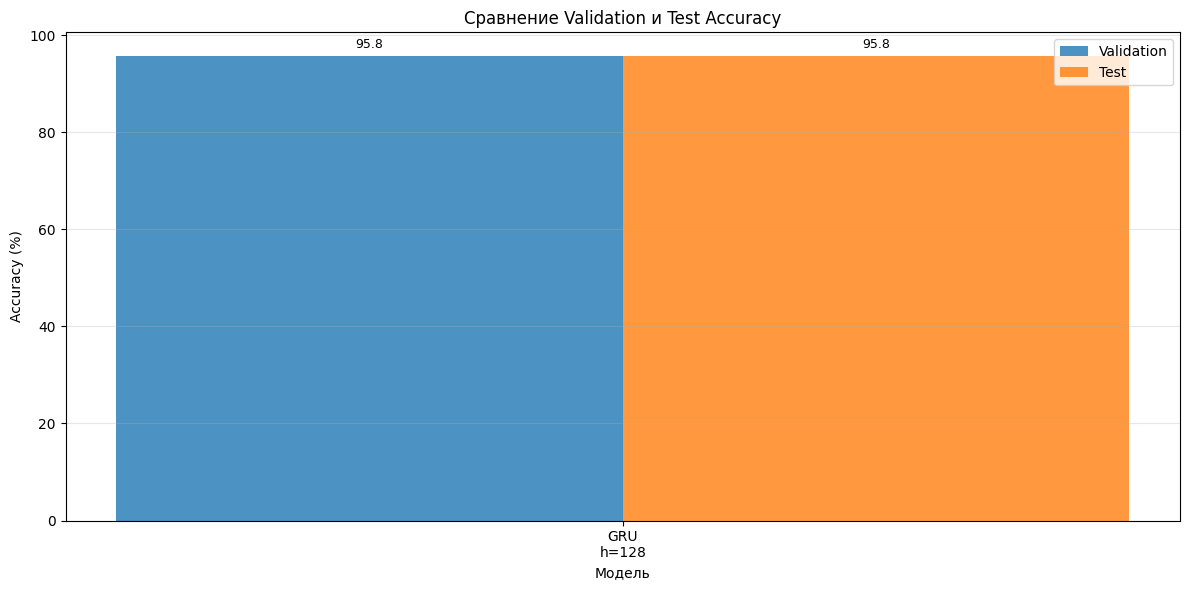

In [26]:
# ============================================
# ЯЧЕЙКА 15: Сравнение с другими моделями
# ============================================

print("=== СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ ===\n")

# Собираем результаты всех моделей на тесте
all_models_comparison = []

for model_name in results.keys():
    model_type = model_name.split('_')[0]
    hidden = int(model_name.split('_h')[1])
    
    # Загружаем сохранённую модель
    if model_type == 'RNN':
        test_model = RNNModel(input_size, hidden, num_layers, num_classes).to(device)
    elif model_type == 'LSTM':
        test_model = LSTMModel(input_size, hidden, num_layers, num_classes).to(device)
    else:
        test_model = GRUModel(input_size, hidden, num_layers, num_classes).to(device)
    
    # Пытаемся загрузить веса
    model_file = f'best_model_{model_type}_h{hidden}.pth'
    try:
        test_model.load_state_dict(torch.load(model_file))
        test_model.eval()
        
        # Тестирование
        test_correct = 0
        test_total = 0
        with torch.no_grad():
            for data, targets, lengths in test_loader:
                data, targets = data.to(device), targets.to(device)
                outputs = test_model(data, lengths)
                test_correct += (outputs.argmax(1) == targets).sum().item()
                test_total += targets.size(0)
        
        test_acc = 100. * test_correct / test_total
        
        all_models_comparison.append({
            'Модель': model_type,
            'Hidden Size': hidden,
            'Val Acc (%)': results[model_name]['best_val_acc'],
            'Test Acc (%)': test_acc
        })
    except:
        print(f" Не удалось загрузить {model_file}")

# Сравнительная таблица
comparison_df = pd.DataFrame(all_models_comparison).sort_values('Test Acc (%)', ascending=False)

print("\nСРАВНИТЕЛЬНАЯ ТАБЛИЦА ВСЕХ МОДЕЛЕЙ:")
print(comparison_df.to_string(index=False))

# График сравнения
plt.figure(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.35

plt.bar(x - width/2, comparison_df['Val Acc (%)'], width, label='Validation', alpha=0.8)
plt.bar(x + width/2, comparison_df['Test Acc (%)'], width, label='Test', alpha=0.8)

plt.xlabel('Модель')
plt.ylabel('Accuracy (%)')
plt.title('Сравнение Validation и Test Accuracy')
plt.xticks(x, [f"{row['Модель']}\nh={row['Hidden Size']}" for _, row in comparison_df.iterrows()])
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

for i, row in comparison_df.iterrows():
    plt.text(i - width/2, row['Val Acc (%)'] + 1, f"{row['Val Acc (%)']:.1f}", 
             ha='center', va='bottom', fontsize=9)
    plt.text(i + width/2, row['Test Acc (%)'] + 1, f"{row['Test Acc (%)']:.1f}", 
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [30]:
# ============================================
# ЯЧЕЙКА 16: Финальный вывод
# ============================================

print("\n" + "="*70)
print("ИТОГОВЫЙ ОТЧЁТ")
print("="*70)

print(f"\nДАТАСЕТ: Japanese Vowels")
print(f"   - Количество образцов: {len(sequences)}")
print(f"   - Количество классов: {num_classes}")
print(f"   - Количество признаков: {input_size}")
print(f"   - Диапазон длин последовательностей: {min(len(s) for s in sequences)}-{max(len(s) for s in sequences)}")

print(f"\nЛУЧШАЯ МОДЕЛЬ:")
print(f"   - Архитектура: {best_model_name}")
print(f"   - Hidden size: {best_hidden}")
print(f"   - Количество слоёв: {num_layers}")
print(f"   - Вариант: Bidirectional" if best_model_name == "GRU" else "   - Вариант: Стандартный")

print(f"\nРЕЗУЛЬТАТЫ:")
print(f"   - Validation Accuracy: {best_val_acc:.2f}%")
print(f"   - Test Accuracy: {test_accuracy:.2f}%")
print(f"   - Precision: {precision:.2f}%")
print(f"   - Recall: {recall:.2f}%")
print(f"   - F1-Score: {f1:.2f}%")


ИТОГОВЫЙ ОТЧЁТ

ДАТАСЕТ: Japanese Vowels
   - Количество образцов: 640
   - Количество классов: 9
   - Количество признаков: 12
   - Диапазон длин последовательностей: 7-29

ЛУЧШАЯ МОДЕЛЬ:
   - Архитектура: GRU
   - Hidden size: 128
   - Количество слоёв: 2
   - Вариант: Bidirectional

РЕЗУЛЬТАТЫ:
   - Validation Accuracy: 95.83%
   - Test Accuracy: 95.83%
   - Precision: 96.05%
   - Recall: 95.83%
   - F1-Score: 95.80%
